### Régression Lasso

Nous allons effectuer une régression lasso afin de sélectionner les variables explicatives les plus pertinentes.
Cette méthode permet d’introduire une pénalisation qui contraint certains coefficients à zéro, réalisant ainsi une sélection automatique des variables.
Elle est particulièrement adaptée dans un contexte de multicolinéarité et permet de réduire la dimension du problème tout en conservant les variables les plus explicatives.

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [110]:
df_clean = pd.read_csv("data/df_clean.csv")

/tmp/ipykernel_116596/1464619808.py:1: DtypeWarning: Columns (0,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("data/df_clean.csv")


Préparation des variables pour la régression lasso

Choix de la cible

In [111]:
target = "taux_equipement_ve"

Supprimer les lignes où la cible manque

In [112]:
df = df_clean[df_clean[target].notna()].copy()
print(df.shape)
print(df_clean.shape)

(35206, 17)
(35206, 17)


L’intégration de la dimension géographique a initialement posé une difficulté liée à la nature de la variable CODGEO. Ce code, correspondant à l’identifiant unique de chaque commune, comporte un très grand nombre de modalités (plus de 35 000), ce qui le rend inutilisable tel quel dans un modèle de régression. Une première approche a consisté à en extraire le département, mais l’encodage de cette variable sous forme de variables indicatrices (one-hot encoding) a conduit à un nombre trop élevé de colonnes, complexifiant le modèle et risquant de dégrader sa stabilité. Afin de conserver une information géographique pertinente tout en maîtrisant la dimension du problème, il a été choisi d’agréger cette information au niveau régional. Les régions présentent un compromis intéressant : elles permettent de capter les effets territoriaux (politiques publiques, infrastructures, dynamiques économiques) tout en limitant le nombre de modalités. Cette transformation améliore ainsi la lisibilité et la robustesse du modèle, tout en conservant une information géographique exploitable.

In [143]:
# Copie de travail
df = df.copy()

# Nettoyer CODGEO
df["CODGEO"] = df["CODGEO"].astype(str).str.strip()

# Supprimer anciennes colonnes géographiques si elles existent
geo_cols = [col for col in df.columns if col.startswith("departement_") or col.startswith("region_")]
df = df.drop(columns=geo_cols, errors="ignore")
df = df.drop(columns=["departement", "region"], errors="ignore")

# Extraire le département
df["departement"] = df["CODGEO"].str[:2]
df.loc[df["CODGEO"].str.startswith("2A"), "departement"] = "2A"
df.loc[df["CODGEO"].str.startswith("2B"), "departement"] = "2B"

In [ ]:
# Dictionnaire des régions et départements
dept_to_region = {
    "01": "Auvergne-Rhone-Alpes", "03": "Auvergne-Rhone-Alpes", "07": "Auvergne-Rhone-Alpes",
    "15": "Auvergne-Rhone-Alpes", "26": "Auvergne-Rhone-Alpes", "38": "Auvergne-Rhone-Alpes",
    "42": "Auvergne-Rhone-Alpes", "43": "Auvergne-Rhone-Alpes", "63": "Auvergne-Rhone-Alpes",
    "69": "Auvergne-Rhone-Alpes", "73": "Auvergne-Rhone-Alpes", "74": "Auvergne-Rhone-Alpes",

    "21": "Bourgogne-Franche-Comte", "25": "Bourgogne-Franche-Comte", "39": "Bourgogne-Franche-Comte",
    "58": "Bourgogne-Franche-Comte", "70": "Bourgogne-Franche-Comte", "71": "Bourgogne-Franche-Comte",
    "89": "Bourgogne-Franche-Comte", "90": "Bourgogne-Franche-Comte",

    "22": "Bretagne", "29": "Bretagne", "35": "Bretagne", "56": "Bretagne",

    "18": "Centre-Val de Loire", "28": "Centre-Val de Loire", "36": "Centre-Val de Loire",
    "37": "Centre-Val de Loire", "41": "Centre-Val de Loire", "45": "Centre-Val de Loire",

    "2A": "Corse", "2B": "Corse",

    "08": "Grand Est", "10": "Grand Est", "51": "Grand Est", "52": "Grand Est",
    "54": "Grand Est", "55": "Grand Est", "57": "Grand Est", "67": "Grand Est",
    "68": "Grand Est", "88": "Grand Est",

    "02": "Hauts-de-France", "59": "Hauts-de-France", "60": "Hauts-de-France",
    "62": "Hauts-de-France", "80": "Hauts-de-France",

    "75": "Ile-de-France", "77": "Ile-de-France", "78": "Ile-de-France", "91": "Ile-de-France",
    "92": "Ile-de-France", "93": "Ile-de-France", "94": "Ile-de-France", "95": "Ile-de-France",

    "14": "Normandie", "27": "Normandie", "50": "Normandie", "61": "Normandie", "76": "Normandie",

    "16": "Nouvelle-Aquitaine", "17": "Nouvelle-Aquitaine", "19": "Nouvelle-Aquitaine",
    "23": "Nouvelle-Aquitaine", "24": "Nouvelle-Aquitaine", "33": "Nouvelle-Aquitaine",
    "40": "Nouvelle-Aquitaine", "47": "Nouvelle-Aquitaine", "64": "Nouvelle-Aquitaine",
    "79": "Nouvelle-Aquitaine", "86": "Nouvelle-Aquitaine", "87": "Nouvelle-Aquitaine",

    "09": "Occitanie", "11": "Occitanie", "12": "Occitanie", "30": "Occitanie",
    "31": "Occitanie", "32": "Occitanie", "34": "Occitanie", "46": "Occitanie",
    "48": "Occitanie", "65": "Occitanie", "66": "Occitanie", "81": "Occitanie", "82": "Occitanie",

    "44": "Pays de la Loire", "49": "Pays de la Loire", "53": "Pays de la Loire",
    "72": "Pays de la Loire", "85": "Pays de la Loire",

    "04": "Provence-Alpes-Cote d'Azur", "05": "Provence-Alpes-Cote d'Azur",
    "06": "Provence-Alpes-Cote d'Azur", "13": "Provence-Alpes-Cote d'Azur",
    "83": "Provence-Alpes-Cote d'Azur", "84": "Provence-Alpes-Cote d'Azur",

    "971": "Outre-Mer", "972": "Outre-Mer", "973": "Outre-Mer",
    "974": "Outre-Mer", "976": "Outre-Mer"
}

In [144]:
# gestion DROM-COM simples
df["departement_long"] = df["CODGEO"].str[:3]
df.loc[df["departement_long"].isin(["971", "972", "973", "974", "976"]), "departement"] = df["departement_long"]

# mapper vers la région
df["region"] = df["departement"].map(dept_to_region)

# catégorie de secours
df["region"] = df["region"].fillna("Autre")

Pour connaître le nombre d'observations par région et le nombre de regions considérées :

In [145]:
print(df["region"].value_counts(dropna=False))
print("Nombre de régions :", df["region"].nunique())

region
Grand Est                     5010
Occitanie                     4672
Nouvelle-Aquitaine            4498
Bourgogne-Franche-Comte       3995
Auvergne-Rhone-Alpes          3507
Hauts-de-France               3412
Normandie                     2820
Centre-Val de Loire           1831
Ile-de-France                 1424
Pays de la Loire              1308
Bretagne                      1291
Provence-Alpes-Cote d'Azur     857
Corse                          364
Outre-Mer                      139
Autre                           78
Name: count, dtype: int64
Nombre de régions : 15


One-hot encoding, pour transformer les variables régions catégorielles en 0 ou en 1

In [153]:
df = pd.get_dummies(df, columns=["region"], drop_first=True, dtype=int)

In [154]:
df

,CODGEO,taux_equipement_ve,total_pdc,puissance_moyenne,puissance_max,nb_operateurs,pct_combo_ccs,pct_paiement_cb,pct_paiement_autre,top_operateur,...,region_Corse,region_Grand Est,region_Hauts-de-France,region_Ile-de-France,region_Normandie,region_Nouvelle-Aquitaine,region_Occitanie,region_Outre-Mer,region_Pays de la Loire,region_Provence-Alpes-Cote d'Azur
0,1002,0.017483,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0,1,0,0,0,0,0,0,0,0
1,1004,0.032214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0,1,0,0,0,0,0,0,0,0
2,1005,0.029488,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0,1,0,0,0,0,0,0,0,0
3,1007,0.032400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0,1,0,0,0,0,0,0,0,0
4,1009,0.022075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35201,97612,0.003136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0,0,0,0,0,0,0,1,0,0
35202,97615,0.001649,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0,0,0,0,0,0,0,1,0,0
35203,97699,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0,0,0,0,0,0,0,1,0,0
35204,97801,0.042105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0,0,0,0,0,0,0,0,0,0


Vérification de l'encodage

In [155]:
region_cols = [col for col in df.columns if col.startswith("region_")]
print(region_cols)
print(df[region_cols].head())
print(df[region_cols].dtypes)

['region_Auvergne-Rhone-Alpes', 'region_Bourgogne-Franche-Comte', 'region_Bretagne', 'region_Centre-Val de Loire', 'region_Corse', 'region_Grand Est', 'region_Hauts-de-France', 'region_Ile-de-France', 'region_Normandie', 'region_Nouvelle-Aquitaine', 'region_Occitanie', 'region_Outre-Mer', 'region_Pays de la Loire', "region_Provence-Alpes-Cote d'Azur"]
   region_Auvergne-Rhone-Alpes  region_Bourgogne-Franche-Comte  \
0                            0                               0   
1                            0                               0   
2                            0                               0   
3                            0                               0   
4                            0                               0   

   region_Bretagne  region_Centre-Val de Loire  region_Corse  \
0                0                           0             0   
1                0                           0             0   
2                0                           0           

In [156]:
df[region_cols].sum(axis=1).value_counts()

1    35128
0       78
Name: count, dtype: int64

Afin d’intégrer une dimension géographique sans augmenter excessivement la dimension du problème, l’information communale a été agrégée au niveau régional. Les codes de communes ont d’abord permis d’identifier le département, puis celui-ci a été associé à sa région administrative. Cette variable régionale a ensuite été encodée sous forme de variables indicatrices, ce qui permet de capter les effets territoriaux tout en conservant un modèle lisible et statistiquement plus stable.

Regarder s’il reste des colonnes object

In [157]:
object_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Colonnes object restantes :", object_cols)

Colonnes object restantes : ['CODGEO', 'top_operateur', 'Libellé géographique', 'departement', 'departement_long']


supprimons ces variables

In [158]:
df_propre = df.drop(columns=[
    "CODGEO",
    "top_operateur",
    "Libellé géographique",
    "departement",
    "departement_long"
], errors="ignore")

In [159]:
# vérification
print(df_propre.select_dtypes(include=["object"]).columns)

Index([], dtype='object')


In [126]:
df_propre

,taux_equipement_ve,total_pdc,puissance_moyenne,puissance_max,nb_operateurs,pct_combo_ccs,pct_paiement_cb,pct_paiement_autre,prive,public,...,region_Corse,region_Grand Est,region_Hauts-de-France,region_Ile-de-France,region_Normandie,region_Nouvelle-Aquitaine,region_Occitanie,region_Outre-Mer,region_Pays de la Loire,region_Provence-Alpes-Cote d'Azur
0,0.017483,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
1,0.032214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
2,0.029488,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
3,0.032400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
4,0.022075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35201,0.003136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
35202,0.001649,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
35203,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
35204,0.042105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


Vérification des valeurs manquantes

In [160]:
print(df_propre.isna().sum().sum())

31700


In [129]:
na_par_col = df_propre.isna().sum().sort_values(ascending=False)
print(na_par_col[na_par_col > 0])

[DISP] Nbre de personnes dans les ménages fiscaux    15850
[DISP] Médiane (€)                                   15850
dtype: int64


In [130]:
# indicateurs
df_propre["revenu_manquant"] = df_propre["[DISP] Médiane (€)"].isna().astype(int)
df_propre["population_manquante"] = df_propre["[DISP] Nbre de personnes dans les ménages fiscaux"].isna().astype(int)

# imputation
df_propre["[DISP] Médiane (€)"] = df_propre["[DISP] Médiane (€)"].fillna(
    df_propre["[DISP] Médiane (€)"].median()
)

df_propre["[DISP] Nbre de personnes dans les ménages fiscaux"] = df_propre[
    "[DISP] Nbre de personnes dans les ménages fiscaux"
].fillna(
    df_propre["[DISP] Nbre de personnes dans les ménages fiscaux"].median()
)

Deux variables importantes ont été conservées malgré un taux de valeurs manquantes d’environ 45 % :

[DISP] Médiane (€)
[DISP] Nbre de personnes dans les ménages fiscaux

Ces variables présentent un fort pouvoir explicatif vis-à-vis du taux d’équipement en véhicules électriques.

Les valeurs manquantes de ces variables ont été imputées par la médiane :
- méthode robuste aux valeurs extrêmes
- adaptée aux distributions asymétriques

Afin de conserver l’information liée à l’absence de données, des variables indicatrices ont été introduites :
- revenu_manquant
- population_manquante

Ces variables prennent la valeur :
- 1 si la donnée est manquante
- 0 sinon

Cela permet au modèle de capter un éventuel effet lié à l’absence d’information.

In [131]:
print(df_propre.isna().sum().sum())

0


Il n'y a plus de valeurs manquantes

#### Regression Lasso

La variable cible présentant une forte asymétrie, une transformation logarithmique a été envisagée afin de stabiliser la variance et de réduire l’influence des valeurs extrêmes.
Cette transformation est particulièrement pertinente pour les modèles linéaires tels que la régression Lasso.
En revanche, pour les modèles non paramétriques comme les forêts aléatoires, cette transformation est moins déterminante, mais a été testée à titre de comparaison.

In [132]:
X = df_propre.drop(columns=["taux_equipement_ve"])
y = np.log1p(df_propre["taux_equipement_ve"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

1. Standardisation des variables

In [133]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

2. Entraînement avec LassoCV (choix automatique du $\alpha$)

In [134]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=42))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True


3. Sélection des variables

In [135]:
lasso = pipeline.named_steps["lasso"]

coef = pd.Series(lasso.coef_, index=X.columns)

# Variables sélectionnées (coeff ≠ 0)
selected_features = coef[coef != 0].index.tolist()

print("Variables sélectionnées :")
print(selected_features)

Variables sélectionnées :
['total_pdc', 'puissance_moyenne', 'nb_operateurs', 'pct_paiement_cb', 'pct_paiement_autre', 'prive', 'public', 'rapide', 'voirie', '[DISP] Médiane (€)', '[DISP] Nbre de personnes dans les ménages fiscaux', 'region_Bourgogne-Franche-Comte', 'region_Bretagne', 'region_Centre-Val de Loire', 'region_Corse', 'region_Grand Est', 'region_Hauts-de-France', 'region_Ile-de-France', 'region_Normandie', 'region_Nouvelle-Aquitaine', 'region_Occitanie', 'region_Outre-Mer', 'region_Pays de la Loire', "region_Provence-Alpes-Cote d'Azur", 'revenu_manquant', 'population_manquante']


<Axes: >

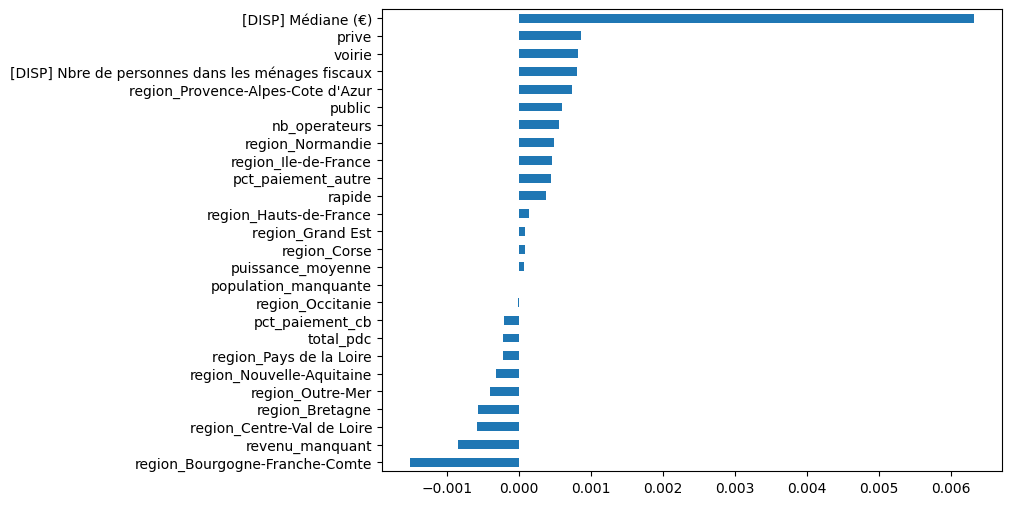

In [136]:
coef[coef != 0].sort_values().plot(kind="barh", figsize=(8,6))

4. Évaluation du modèle

In [137]:
print("Score train :", pipeline.score(X_train, y_train))
print("Score test :", pipeline.score(X_test, y_test))

Score train : 0.19875029298295177
Score test : 0.2626547329998544


In [138]:
#variables éliminées
remouved_features = coef[coef == 0].index.tolist()
print(coef[coef == 0].sort_values())
print(len(remouved_features))

puissance_max                 -0.0
pct_combo_ccs                  0.0
region_Auvergne-Rhone-Alpes    0.0
dtype: float64
3


3 variables sont annulées : puissance_max, pct_combo_ccs et region_Auvergne-Rhone-Alpes

In [139]:
print(selected_features)

['total_pdc', 'puissance_moyenne', 'nb_operateurs', 'pct_paiement_cb', 'pct_paiement_autre', 'prive', 'public', 'rapide', 'voirie', '[DISP] Médiane (€)', '[DISP] Nbre de personnes dans les ménages fiscaux', 'region_Bourgogne-Franche-Comte', 'region_Bretagne', 'region_Centre-Val de Loire', 'region_Corse', 'region_Grand Est', 'region_Hauts-de-France', 'region_Ile-de-France', 'region_Normandie', 'region_Nouvelle-Aquitaine', 'region_Occitanie', 'region_Outre-Mer', 'region_Pays de la Loire', "region_Provence-Alpes-Cote d'Azur", 'revenu_manquant', 'population_manquante']


In [140]:
df_selected = X[selected_features]

In [141]:
df_selected.to_csv("data/df_selected.csv", index=False)

In [161]:
df_selected

,total_pdc,puissance_moyenne,nb_operateurs,pct_paiement_cb,pct_paiement_autre,prive,public,rapide,voirie,[DISP] Médiane (€),...,region_Hauts-de-France,region_Ile-de-France,region_Normandie,region_Nouvelle-Aquitaine,region_Occitanie,region_Outre-Mer,region_Pays de la Loire,region_Provence-Alpes-Cote d'Azur,revenu_manquant,population_manquante
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,0,0,0,0,0,0,0,0,1,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,0,0,0,0,0,0,0,0,1,1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,0,0,0,0,0,0,0,0,1,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,0,0,0,0,0,0,0,0,1,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,0,0,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,0,0,0,0,0,1,0,0,1,1
35202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,0,0,0,0,0,1,0,0,1,1
35203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,0,0,0,0,0,1,0,0,1,1
35204,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22880.0,...,0,0,0,0,0,0,0,0,1,1


La régression Lasso met en évidence le rôle prépondérant du revenu médian dans l’explication du taux d’équipement en véhicules électriques.
Les variables liées à l’infrastructure de recharge apparaissent également comme significatives, bien que leur impact reste secondaire.
L’introduction d’une dimension géographique via les régions permet de mettre en évidence des disparités territoriales marquées, certaines régions présentant un niveau d’équipement plus élevé que d’autres, toutes choses égales par ailleurs.
Enfin, la variable indicatrice de données manquantes sur le revenu met en évidence un effet structurel, suggérant que les territoires moins bien documentés ou moins développés présentent un retard dans l’adoption des véhicules électriques.
Les véhicules électriques sont d’abord un phénomène économique, puis infrastructurel, et enfin territorial.